## 1. Notebook Setup

Started by setting up the notebook paths and importing the packages needed for the project. Helper functions are kept in `src/credit_default_pipeline.py` so the same cleaning and modeling code can be reused without rewriting it in every cell.

In [1]:
from pathlib import Path
import json
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

LOCAL_PACKAGES = PROJECT_ROOT / 'work' / 'packages'
if LOCAL_PACKAGES.exists():
    sys.path.insert(0, str(LOCAL_PACKAGES))

sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import credit_default_pipeline as pipeline

RAW = PROJECT_ROOT / 'data' / 'raw'
OUTPUTS = PROJECT_ROOT / 'outputs'
FIGURES = PROJECT_ROOT / 'reports' / 'figures'

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 140)
plt.style.use('default')

PROJECT_ROOT

Matplotlib is building the font cache; this may take a moment.


PosixPath('/Users/sarahai/Desktop/Gradient Boosting Model - Home Credit Default Risk')

## 2. Check Data Files

Before doing any modeling, checked which Kaggle files were actually in the project folder. This makes sure the notebook uses the real Home Credit files and not demo data.

In [2]:
expected_files = [
    'application_train.csv',
    'application_test.csv',
    'bureau.csv',
    'previous_application.csv',
    'installments_payments.csv',
]

file_status = pd.DataFrame({
    'file': expected_files,
    'exists': [(RAW / f).exists() for f in expected_files],
    'size_mb': [round((RAW / f).stat().st_size / 1024**2, 2) if (RAW / f).exists() else None for f in expected_files],
})
file_status

,file,exists,size_mb
0,application_train.csv,True,158.44
1,application_test.csv,True,25.34
2,bureau.csv,True,162.14
3,previous_application.csv,True,386.21
4,installments_payments.csv,True,689.62


## 3. Load the Main Train and Test Data

Next Loaded the main train and test files. The train file has the `TARGET` column, so it is used for training and validation. The test file does not have `TARGET`, so it is used at the end for the Kaggle submission.

In [3]:
train_raw = pd.read_csv(RAW / 'application_train.csv')
test_raw = pd.read_csv(RAW / 'application_test.csv')

print('Training shape:', train_raw.shape)
print('Test shape:', test_raw.shape)

Training shape: (307511, 122)
Test shape: (48744, 121)


In [4]:
train_raw.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,...,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,...,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,...,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-815.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,-19005,-3039,-9833.0,-2437,NaN,1,1,0,1,0,0,Laborers,2.0,2,2,WEDNESDAY,17,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,2.0,0.0,-617.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.028663,-19932,-3038,-4311.0,-3458,NaN,1,1,0,1,0,0,Core staff,1.0,2,2,THURSDAY,11,0,0,0,0,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-1106.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


### Quick Numeric Summary

Looked at the main money-related columns first. Income, credit amount, annuity, and goods price seemed like useful starting points because they describe the size of the loan compared with the applicant's finances.

In [5]:
main_amount_cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']
train_raw[main_amount_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1615.5,16524.0,24903.0,34596.0,258025.5
AMT_GOODS_PRICE,307233.0,538396.207429,369446.460540,40500.0,238500.0,450000.0,679500.0,4050000.0


## 4. Target Distribution

Then Checked the target distribution. This matters because default data is usually imbalanced, meaning there are many more non-default cases than default cases. Because of that, The project focuses on AUC instead of just accuracy.

In [6]:
target_counts = train_raw['TARGET'].value_counts().sort_index()
target_share = train_raw['TARGET'].value_counts(normalize=True).sort_index()

target_table = pd.DataFrame({
    'count': target_counts,
    'share': target_share,
})
target_table

,count,share
TARGET,,
0,282686,0.919271
1,24825,0.080729


### Target Distribution Graph

Created a simple bar chart to see the share of non-default and default applicants. `0` means no repayment difficulty, and `1` means repayment difficulty.

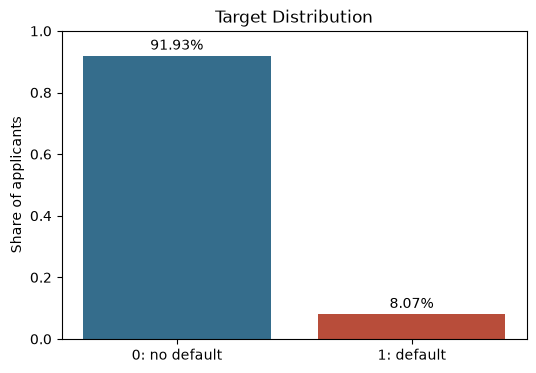

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
labels = ['0: no default', '1: default']
ax.bar(labels, target_share.values, color=['#356d8c', '#b84d3a'])
ax.set_title('Target Distribution')
ax.set_ylabel('Share of applicants')
ax.set_ylim(0, 1)
for i, value in enumerate(target_share.values):
    ax.text(i, value + 0.02, f'{value:.2%}', ha='center')
plt.show()

## 5. Missing Values

After that, Checked missing values. There are a lot of missing entries in this dataset, so dropping rows would lose too much data. Summarized missingness first and handled it later during preprocessing.

In [8]:
missing = pipeline.missing_summary(train_raw)
missing.head(20)

,column,missing_count,missing_pct,dtype
48,COMMONAREA_AVG,214865,69.87,float64
62,COMMONAREA_MODE,214865,69.87,float64
76,COMMONAREA_MEDI,214865,69.87,float64
56,NONLIVINGAPARTMENTS_AVG,213514,69.43,float64
70,NONLIVINGAPARTMENTS_MODE,213514,69.43,float64
84,NONLIVINGAPARTMENTS_MEDI,213514,69.43,float64
86,FONDKAPREMONT_MODE,210295,68.39,str
54,LIVINGAPARTMENTS_AVG,210199,68.35,float64
68,LIVINGAPARTMENTS_MODE,210199,68.35,float64
82,LIVINGAPARTMENTS_MEDI,210199,68.35,float64


### Missing Values Graph

Graphed the columns with the highest missing percentages to see where the biggest gaps were.

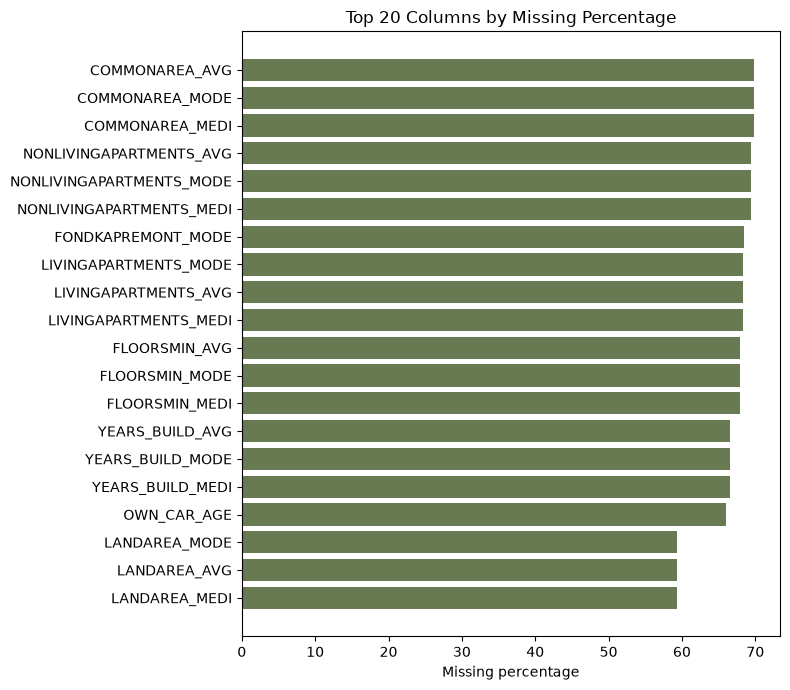

In [9]:
top_missing = missing.head(20).sort_values('missing_pct')

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top_missing['column'], top_missing['missing_pct'], color='#687a52')
ax.set_title('Top 20 Columns by Missing Percentage')
ax.set_xlabel('Missing percentage')
plt.tight_layout()
plt.show()

## 6. Look at the Secondary Tables

The main application table only shows information from the current application. Also used secondary tables because they give more history about the applicant.

- `bureau.csv`: previous credit history from external bureaus
- `previous_application.csv`: earlier Home Credit applications
- `installments_payments.csv`: actual payment behavior

These were expected to help because past borrowing and repayment behavior should be related to future default risk.

In [10]:
bureau_raw = pd.read_csv(RAW / 'bureau.csv', nrows=5)
previous_raw = pd.read_csv(RAW / 'previous_application.csv', nrows=5)
installments_raw = pd.read_csv(RAW / 'installments_payments.csv', nrows=5)

print('bureau sample')
display(bureau_raw)
print('previous applications sample')
display(previous_raw)
print('installments sample')
display(installments_raw)

bureau sample


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


previous applications sample


,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,FLAG_LAST_APPL_PER_CONTRACT,NFLAG_LAST_APPL_IN_DAY,RATE_DOWN_PAYMENT,RATE_INTEREST_PRIMARY,RATE_INTEREST_PRIVILEGED,NAME_CASH_LOAN_PURPOSE,NAME_CONTRACT_STATUS,DAYS_DECISION,NAME_PAYMENT_TYPE,CODE_REJECT_REASON,NAME_TYPE_SUITE,NAME_CLIENT_TYPE,NAME_GOODS_CATEGORY,NAME_PORTFOLIO,NAME_PRODUCT_TYPE,CHANNEL_TYPE,SELLERPLACE_AREA,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,Y,1,0.0,0.182832,0.867336,XAP,Approved,-73,Cash through the bank,XAP,NaN,Repeater,Mobile,POS,XNA,Country-wide,35,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-164,XNA,XAP,Unaccompanied,Repeater,XNA,Cash,x-sell,Contact center,-1,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-301,Cash through the bank,XAP,"Spouse, partner",Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,Y,1,NaN,NaN,NaN,XNA,Approved,-512,Cash through the bank,XAP,NaN,Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,Y,1,NaN,NaN,NaN,Repairs,Refused,-781,Cash through the bank,HC,NaN,Repeater,XNA,Cash,walk-in,Credit and cash offices,-1,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


installments sample


,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585


## 7. Aggregate the Secondary Tables

Each secondary table has multiple rows for the same applicant. Since the model needs one row per applicant, Aggregated each table by `SK_ID_CURR`. Used counts, averages, maximums, minimums, sums, and category shares.

In [11]:
bureau_features = pipeline.aggregate_bureau_features()
previous_features = pipeline.aggregate_previous_application_features()
installment_features = pipeline.aggregate_installment_features()

secondary_summary = pd.DataFrame({
    'table': ['bureau', 'previous_application', 'installments_payments'],
    'rows_after_aggregation': [len(bureau_features), len(previous_features), len(installment_features)],
    'columns_after_aggregation': [bureau_features.shape[1], previous_features.shape[1], installment_features.shape[1]],
})
secondary_summary

,table,rows_after_aggregation,columns_after_aggregation
0,bureau,305811,71
1,previous_application,338857,64
2,installments_payments,339587,61


In [12]:
bureau_features.head()

,SK_ID_CURR,BUREAU_SK_ID_BUREAU_COUNT,BUREAU_SK_ID_BUREAU_MEAN,BUREAU_SK_ID_BUREAU_MAX,BUREAU_SK_ID_BUREAU_MIN,BUREAU_SK_ID_BUREAU_SUM,BUREAU_DAYS_CREDIT_COUNT,BUREAU_DAYS_CREDIT_MEAN,BUREAU_DAYS_CREDIT_MAX,BUREAU_DAYS_CREDIT_MIN,BUREAU_DAYS_CREDIT_SUM,BUREAU_DAYS_CREDIT_ENDDATE_COUNT,BUREAU_DAYS_CREDIT_ENDDATE_MEAN,BUREAU_DAYS_CREDIT_ENDDATE_MAX,BUREAU_DAYS_CREDIT_ENDDATE_MIN,BUREAU_DAYS_CREDIT_ENDDATE_SUM,BUREAU_DAYS_ENDDATE_FACT_COUNT,BUREAU_DAYS_ENDDATE_FACT_MEAN,BUREAU_DAYS_ENDDATE_FACT_MAX,BUREAU_DAYS_ENDDATE_FACT_MIN,BUREAU_DAYS_ENDDATE_FACT_SUM,BUREAU_CNT_CREDIT_PROLONG_COUNT,BUREAU_CNT_CREDIT_PROLONG_MEAN,BUREAU_CNT_CREDIT_PROLONG_MAX,BUREAU_CNT_CREDIT_PROLONG_MIN,BUREAU_CNT_CREDIT_PROLONG_SUM,BUREAU_AMT_CREDIT_SUM_COUNT,BUREAU_AMT_CREDIT_SUM_MEAN,BUREAU_AMT_CREDIT_SUM_MAX,BUREAU_AMT_CREDIT_SUM_MIN,BUREAU_AMT_CREDIT_SUM_SUM,BUREAU_AMT_CREDIT_SUM_DEBT_COUNT,BUREAU_AMT_CREDIT_SUM_DEBT_MEAN,BUREAU_AMT_CREDIT_SUM_DEBT_MAX,BUREAU_AMT_CREDIT_SUM_DEBT_MIN,BUREAU_AMT_CREDIT_SUM_DEBT_SUM,BUREAU_AMT_CREDIT_SUM_OVERDUE_COUNT,BUREAU_AMT_CREDIT_SUM_OVERDUE_MEAN,BUREAU_AMT_CREDIT_SUM_OVERDUE_MAX,BUREAU_AMT_CREDIT_SUM_OVERDUE_MIN,BUREAU_AMT_CREDIT_SUM_OVERDUE_SUM,BUREAU_AMT_ANNUITY_COUNT,BUREAU_AMT_ANNUITY_MEAN,BUREAU_AMT_ANNUITY_MAX,BUREAU_AMT_ANNUITY_MIN,BUREAU_AMT_ANNUITY_SUM,BUREAU_BUREAU_HAS_DEBT_COUNT,BUREAU_BUREAU_HAS_DEBT_MEAN,BUREAU_BUREAU_HAS_DEBT_MAX,BUREAU_BUREAU_HAS_DEBT_MIN,BUREAU_BUREAU_HAS_DEBT_SUM,BUREAU_BUREAU_HAS_OVERDUE_COUNT,BUREAU_BUREAU_HAS_OVERDUE_MEAN,BUREAU_BUREAU_HAS_OVERDUE_MAX,BUREAU_BUREAU_HAS_OVERDUE_MIN,BUREAU_BUREAU_HAS_OVERDUE_SUM,BUREAU_BUREAU_DEBT_CREDIT_RATIO_RAW_COUNT,BUREAU_BUREAU_DEBT_CREDIT_RATIO_RAW_MEAN,BUREAU_BUREAU_DEBT_CREDIT_RATIO_RAW_MAX,BUREAU_BUREAU_DEBT_CREDIT_RATIO_RAW_MIN,BUREAU_BUREAU_DEBT_CREDIT_RATIO_RAW_SUM,BUREAU_ACTIVE_SHARE_Active,BUREAU_ACTIVE_SHARE_Bad debt,BUREAU_ACTIVE_SHARE_Closed,BUREAU_ACTIVE_SHARE_Sold,BUREAU_TYPE_SHARE_Car loan,BUREAU_TYPE_SHARE_Consumer credit,BUREAU_TYPE_SHARE_Credit card,BUREAU_TYPE_SHARE_Loan for business development,BUREAU_TYPE_SHARE_Microloan,BUREAU_TYPE_SHARE_Mortgage
0,100001,7,5896633.000,5896636,5896630,41276431,7,-735.000000,-49,-1572,-5145,7,82.428571,1778.0,-1329.0,577.0,4,-825.500000,-544.0,-1328.0,-3302.0,7,0.0,0,0,0,7,207623.571429,378000.0,85500.0,1453365.000,7,85240.928571,373239.0,0.0,596686.5,7,0.0,0.0,0.0,0.0,7,3545.357143,10822.5,0.0,24817.5,7,0.428571,1,0,3,7,0.0,0,0,0,7,0.282518,0.987405,0.0,1.977625,0.428571,0.0,0.571429,0.0,0.0,1.000000,0.000000,0.0,0.0,0.0
1,100002,8,6153272.125,6158909,6113835,49226177,8,-874.000000,-103,-1437,-6992,6,-349.000000,780.0,-1072.0,-2094.0,6,-697.500000,-36.0,-1185.0,-4185.0,8,0.0,0,0,0,8,108131.945625,450000.0,0.0,865055.565,5,49156.200000,245781.0,0.0,245781.0,8,0.0,0.0,0.0,0.0,7,0.000000,0.0,0.0,0.0,8,0.125000,1,0,1,8,0.0,0,0,0,4,0.136545,0.546180,0.0,0.546180,0.250000,0.0,0.750000,0.0,0.0,0.500000,0.500000,0.0,0.0,0.0
2,100003,4,5885878.500,5885880,5885877,23543514,4,-1400.750000,-606,-2586,-5603,4,-544.500000,1216.0,-2434.0,-2178.0,3,-1097.333333,-540.0,-2131.0,-3292.0,4,0.0,0,0,0,4,254350.125000,810000.0,22248.0,1017400.500,4,0.000000,0.0,0.0,0.0,4,0.0,0.0,0.0,0.0,0,NaN,NaN,NaN,0.0,4,0.000000,0,0,0,4,0.0,0,0,0,4,0.000000,0.000000,0.0,0.000000,0.250000,0.0,0.750000,0.0,0.0,0.500000,0.500000,0.0,0.0,0.0
3,100004,2,6829133.500,6829134,6829133,13658267,2,-867.000000,-408,-1326,-1734,2,-488.500000,-382.0,-595.0,-977.0,2,-532.500000,-382.0,-683.0,-1065.0,2,0.0,0,0,0,2,94518.900000,94537.8,94500.0,189037.800,2,0.000000,0.0,0.0,0.0,2,0.0,0.0,0.0,0.0,0,NaN,NaN,NaN,0.0,2,0.000000,0,0,0,2,0.0,0,0,0,2,0.000000,0.000000,0.0,0.000000,0.000000,0.0,1.000000,0.0,0.0,1.000000,0.000000,0.0,0.0,0.0
4,100005,3,6735201.000,6735202,6735200,20205603,3,-190.666667,-62,-373,-572,3,439.333333,1324.0,-128.0,1318.0,1,-123.000000,-123.0,-123.0,-123.0,3,0.0,0,0,0,3,219042.000000,568800.0,29826.0,657126.000,3,189469.500000,543087.0,0.0,568408.5,3,0.0,0.0,0.0,0.0,3,1420.500000,4261.5,0.0,4261.5,3,0.666667,1,0,2,3,0.0,0

In [13]:
previous_features.head()

,SK_ID_CURR,PREV_SK_ID_PREV_COUNT,PREV_SK_ID_PREV_MEAN,PREV_SK_ID_PREV_MAX,PREV_SK_ID_PREV_MIN,PREV_SK_ID_PREV_SUM,PREV_AMT_ANNUITY_COUNT,PREV_AMT_ANNUITY_MEAN,PREV_AMT_ANNUITY_MAX,PREV_AMT_ANNUITY_MIN,PREV_AMT_ANNUITY_SUM,PREV_AMT_APPLICATION_COUNT,PREV_AMT_APPLICATION_MEAN,PREV_AMT_APPLICATION_MAX,PREV_AMT_APPLICATION_MIN,PREV_AMT_APPLICATION_SUM,PREV_AMT_CREDIT_COUNT,PREV_AMT_CREDIT_MEAN,PREV_AMT_CREDIT_MAX,PREV_AMT_CREDIT_MIN,PREV_AMT_CREDIT_SUM,PREV_AMT_DOWN_PAYMENT_COUNT,PREV_AMT_DOWN_PAYMENT_MEAN,PREV_AMT_DOWN_PAYMENT_MAX,PREV_AMT_DOWN_PAYMENT_MIN,PREV_AMT_DOWN_PAYMENT_SUM,PREV_HOUR_APPR_PROCESS_START_COUNT,PREV_HOUR_APPR_PROCESS_START_MEAN,PREV_HOUR_APPR_PROCESS_START_MAX,PREV_HOUR_APPR_PROCESS_START_MIN,PREV_HOUR_APPR_PROCESS_START_SUM,PREV_RATE_DOWN_PAYMENT_COUNT,PREV_RATE_DOWN_PAYMENT_MEAN,PREV_RATE_DOWN_PAYMENT_MAX,PREV_RATE_DOWN_PAYMENT_MIN,PREV_RATE_DOWN_PAYMENT_SUM,PREV_DAYS_DECISION_COUNT,PREV_DAYS_DECISION_MEAN,PREV_DAYS_DECISION_MAX,PREV_DAYS_DECISION_MIN,PREV_DAYS_DECISION_SUM,PREV_CNT_PAYMENT_COUNT,PREV_CNT_PAYMENT_MEAN,PREV_CNT_PAYMENT_MAX,PREV_CNT_PAYMENT_MIN,PREV_CNT_PAYMENT_SUM,PREV_PREV_CREDIT_APPLICATION_RATIO_RAW_COUNT,PREV_PREV_CREDIT_APPLICATION_RATIO_RAW_MEAN,PREV_PREV_CREDIT_APPLICATION_RATIO_RAW_MAX,PREV_PREV_CREDIT_APPLICATION_RATIO_RAW_MIN,PREV_PREV_CREDIT_APPLICATION_RATIO_RAW_SUM,PREV_PREV_ANNUITY_CREDIT_RATIO_RAW_COUNT,PREV_PREV_ANNUITY_CREDIT_RATIO_RAW_MEAN,PREV_PREV_ANNUITY_CREDIT_RATIO_RAW_MAX,PREV_PREV_ANNUITY_CREDIT_RATIO_RAW_MIN,PREV_PREV_ANNUITY_CREDIT_RATIO_RAW_SUM,PREV_STATUS_SHARE_Approved,PREV_STATUS_SHARE_Canceled,PREV_STATUS_SHARE_Refused,PREV_STATUS_SHARE_Unused offer,PREV_TYPE_SHARE_Cash loans,PREV_TYPE_SHARE_Consumer loans,PREV_TYPE_SHARE_Revolving loans,PREV_TYPE_SHARE_XNA
0,100001,1,1.369693e+06,1369693,1369693,1369693,1,3951.000,3951.000,3951.000,3951.000,1,24835.50,24835.5,24835.5,24835.5,1,23787.00,23787.0,23787.0,23787.0,1,2520.0,2520.0,2520.0,2520.0,1,13.000000,13,13,13,1,0.104326,0.104326,0.104326,0.104326,1,-1740.0,-1740,-1740,-1740,1,8.0,8.0,8.0,8.0,1,0.957782,0.957782,0.957782,0.957782,1,0.166099,0.166099,0.166099,0.166099,1.0,0.0,0.0,0.0,0.000000,1.000000,0.0,0.0
1,100002,1,1.038818e+06,1038818,1038818,1038818,1,9251.775,9251.775,9251.775,9251.775,1,179055.00,179055.0,179055.0,179055.0,1,179055.00,179055.0,179055.0,179055.0,1,0.0,0.0,0.0,0.0,1,9.000000,9,9,9,1,0.000000,0.000000,0.000000,0.000000,1,-606.0,-606,-606,-606,1,24.0,24.0,24.0,24.0,1,1.000000,1.000000,1.000000,1.000000,1,0.051670,0.051670,0.051670,0.051670,1.0,0.0,0.0,0.0,0.000000,1.000000,0.0,0.0
2,100003,3,2.281150e+06,2636178,1810518,6843451,3,56553.990,98356.995,6737.310,169661.970,3,435436.50,900000.0,68809.5,1306309.5,3,484191.00,1035882.0,68053.5,1452573.0,2,3442.5,6885.0,0.0,6885.0,3,14.666667,17,12,44,2,0.050030,0.100061,0.000000,0.100061,3,-1305.0,-746,-2341,-3915,3,10.0,12.0,6.0,30.0,3,1.057664,1.150980,0.989013,3.172993,3,0.126383,0.185200,0.094950,0.379150,1.0,0.0,0.0,0.0,0.333333,0.666667,0.0,0.0
3,100004,1,1.564014e+06,1564014,1564014,1564014,1,5357.250,5357.250,5357.250,5357.250,1,24282.00,24282.0,24282.0,24282.0,1,20106.00,20106.0,20106.0,20106.0,1,4860.0,4860.0,4860.0,4860.0,1,5.000000,5,5,5,1,0.212008,0.212008,0.212008,0.212008,1,-815.0,-815,-815,-815,1,4.0,4.0,4.0,4.0,1,0.828021,0.828021,0.828021,0.828021,1,0.266450,0.266450,0.266450,0.266450,1.0,0.0,0.0,0.0,0.000000,1.000000,0.0,0.0
4,100005,2,2.176837e+06,2495675,1857999,4353674,1,4813.200,4813.200,4813.200,4813.200,2,22308.75,44617.5,0.0,44617.5,2,20076.75,40153.5,0.0,40153.5,1,4464.0,4464.0,4464.0,4464.0,2,10.500000,11,10,21,1,0.108964,0.108964,0.108964,0.108964,2,-536.0,-315,-757,-1072,1,12.0,12.0,12.0,12.0,1,0.899950,0.899950,0.899950,0.899950,1,0.119870,0.119870,0.119870,0.119870,0.5,0.5,0.0,0.0,0.500000,0.500000,0.0,0.0


In [14]:
installment_features.head()

,SK_ID_CURR,INSTAL_SK_ID_PREV_COUNT,INSTAL_SK_ID_PREV_MEAN,INSTAL_SK_ID_PREV_MAX,INSTAL_SK_ID_PREV_MIN,INSTAL_SK_ID_PREV_SUM,INSTAL_NUM_INSTALMENT_VERSION_COUNT,INSTAL_NUM_INSTALMENT_VERSION_MEAN,INSTAL_NUM_INSTALMENT_VERSION_MAX,INSTAL_NUM_INSTALMENT_VERSION_MIN,INSTAL_NUM_INSTALMENT_VERSION_SUM,INSTAL_NUM_INSTALMENT_NUMBER_COUNT,INSTAL_NUM_INSTALMENT_NUMBER_MEAN,INSTAL_NUM_INSTALMENT_NUMBER_MAX,INSTAL_NUM_INSTALMENT_NUMBER_MIN,INSTAL_NUM_INSTALMENT_NUMBER_SUM,INSTAL_DAYS_INSTALMENT_COUNT,INSTAL_DAYS_INSTALMENT_MEAN,INSTAL_DAYS_INSTALMENT_MAX,INSTAL_DAYS_INSTALMENT_MIN,INSTAL_DAYS_INSTALMENT_SUM,INSTAL_DAYS_ENTRY_PAYMENT_COUNT,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,INSTAL_DAYS_ENTRY_PAYMENT_MAX,INSTAL_DAYS_ENTRY_PAYMENT_MIN,INSTAL_DAYS_ENTRY_PAYMENT_SUM,INSTAL_AMT_INSTALMENT_COUNT,INSTAL_AMT_INSTALMENT_MEAN,INSTAL_AMT_INSTALMENT_MAX,INSTAL_AMT_INSTALMENT_MIN,INSTAL_AMT_INSTALMENT_SUM,INSTAL_AMT_PAYMENT_COUNT,INSTAL_AMT_PAYMENT_MEAN,INSTAL_AMT_PAYMENT_MAX,INSTAL_AMT_PAYMENT_MIN,INSTAL_AMT_PAYMENT_SUM,INSTAL_INSTAL_DAYS_LATE_COUNT,INSTAL_INSTAL_DAYS_LATE_MEAN,INSTAL_INSTAL_DAYS_LATE_MAX,INSTAL_INSTAL_DAYS_LATE_MIN,INSTAL_INSTAL_DAYS_LATE_SUM,INSTAL_INSTAL_IS_LATE_COUNT,INSTAL_INSTAL_IS_LATE_MEAN,INSTAL_INSTAL_IS_LATE_MAX,INSTAL_INSTAL_IS_LATE_MIN,INSTAL_INSTAL_IS_LATE_SUM,INSTAL_INSTAL_PAYMENT_DIFF_COUNT,INSTAL_INSTAL_PAYMENT_DIFF_MEAN,INSTAL_INSTAL_PAYMENT_DIFF_MAX,INSTAL_INSTAL_PAYMENT_DIFF_MIN,INSTAL_INSTAL_PAYMENT_DIFF_SUM,INSTAL_INSTAL_UNDERPAID_COUNT,INSTAL_INSTAL_UNDERPAID_MEAN,INSTAL_INSTAL_UNDERPAID_MAX,INSTAL_INSTAL_UNDERPAID_MIN,INSTAL_INSTAL_UNDERPAID_SUM,INSTAL_INSTAL_PAYMENT_RATIO_RAW_COUNT,INSTAL_INSTAL_PAYMENT_RATIO_RAW_MEAN,INSTAL_INSTAL_PAYMENT_RATIO_RAW_MAX,INSTAL_INSTAL_PAYMENT_RATIO_RAW_MIN,INSTAL_INSTAL_PAYMENT_RATIO_RAW_SUM
0,100001,7,1.576389e+06,1851984,1369693,11034724,7,1.142857,2.0,1.0,8.0,7,2.714286,4,1,19,7,-2187.714286,-1619.0,-2916.0,-15314.0,7,-2195.000000,-1628.0,-2916.0,-15365.0,7,5885.132143,17397.900,3951.000,41195.925,7,5885.132143,17397.900,3951.000,41195.925,7,-7.285714,11.0,-36.0,-51.0,7,0.142857,1,0,1,7,0.0,0.0,0.0,0.0,7,0.0,0,0,0,7,1.0,1.0,1.0,7.0
1,100002,19,1.038818e+06,1038818,1038818,19737542,19,1.052632,2.0,1.0,20.0,19,10.000000,19,1,190,19,-295.000000,-25.0,-565.0,-5605.0,19,-315.421053,-49.0,-587.0,-5993.0,19,11559.247105,53093.745,9251.775,219625.695,19,11559.247105,53093.745,9251.775,219625.695,19,-20.421053,-12.0,-31.0,-388.0,19,0.000000,0,0,0,19,0.0,0.0,0.0,0.0,19,0.0,0,0,0,19,1.0,1.0,1.0,19.0
2,100003,25,2.290070e+06,2636178,1810518,57251754,25,1.040000,2.0,1.0,26.0,25,5.080000,12,1,127,25,-1378.160000,-536.0,-2310.0,-34454.0,25,-1385.320000,-544.0,-2324.0,-34633.0,25,64754.586000,560835.360,6662.970,1618864.650,25,64754.586000,560835.360,6662.970,1618864.650,25,-7.160000,-1.0,-14.0,-179.0,25,0.000000,0,0,0,25,0.0,0.0,0.0,0.0,25,0.0,0,0,0,25,1.0,1.0,1.0,25.0
3,100004,3,1.564014e+06,1564014,1564014,4692042,3,1.333333,2.0,1.0,4.0,3,2.000000,3,1,6,3,-754.000000,-724.0,-784.0,-2262.0,3,-761.666667,-727.0,-795.0,-2285.0,3,7096.155000,10573.965,5357.250,21288.465,3,7096.155000,10573.965,5357.250,21288.465,3,-7.666667,-3.0,-11.0,-23.0,3,0.000000,0,0,0,3,0.0,0.0,0.0,0.0,3,0.0,0,0,0,3,1.0,1.0,1.0,3.0
4,100005,9,2.495675e+06,2495675,2495675,22461075,9,1.111111,2.0,1.0,10.0,9,5.000000,9,1,45,9,-586.000000,-466.0,-706.0,-5274.0,9,-609.555556,-470.0,-736.0,-5486.0,9,6240.205000,17656.245,4813.200,56161.845,9,6240.205000,17656.245,4813.200,56161.845,9,-23.555556,1.0,-37.0,-212.0,9,0.111111,1,0,1,9,0.0,0.0,0.0,0.0,9,0.0,0,0,0,9,1.0,1.0,1.0,9.0


## 8. Merge the Secondary Features

Once the secondary tables were aggregated, merged them back into the main train and test tables. This created a richer applicant-level dataset while still keeping one row per applicant.

In [15]:
train, test, secondary_tables = pipeline.add_secondary_table_features(train_raw, test_raw)

print('Merged train shape:', train.shape)
print('Merged test shape:', test.shape)
print('Secondary tables used:', secondary_tables)

Merged train shape: (307511, 315)
Merged test shape: (48744, 314)
Secondary tables used: ['bureau', 'previous_application', 'installments_payments']


## 9. Feature Engineering

Then Added features that made sense for a credit-risk problem. Some examples are:

- credit amount relative to income
- annuity relative to income
- income per family member
- external credit score averages
- missing value count
- late payment and underpayment summaries from installments

In [16]:
cleaned_train = pipeline.clean_known_anomalies(train)

engineered_cols = [
    'MISSING_VALUE_COUNT', 'DAYS_EMPLOYED_ANOM', 'AGE_YEARS', 'EMPLOYED_AGE_RATIO',
    'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_TERM', 'CREDIT_GOODS_RATIO',
    'GOODS_INCOME_RATIO', 'INCOME_PER_PERSON', 'CREDIT_PER_CHILD', 'EXT_SOURCE_MEAN',
    'EXT_SOURCE_STD', 'EXT_SOURCE_MIN', 'EXT_SOURCE_MAX', 'EXT_SOURCE_PRODUCT',
]
engineered_cols = [c for c in engineered_cols if c in cleaned_train.columns]
engineered_cols

['MISSING_VALUE_COUNT',
 'DAYS_EMPLOYED_ANOM',
 'AGE_YEARS',
 'EMPLOYED_AGE_RATIO',
 'CREDIT_INCOME_RATIO',
 'ANNUITY_INCOME_RATIO',
 'CREDIT_TERM',
 'CREDIT_GOODS_RATIO',
 'GOODS_INCOME_RATIO',
 'INCOME_PER_PERSON',
 'CREDIT_PER_CHILD',
 'EXT_SOURCE_MEAN',
 'EXT_SOURCE_STD',
 'EXT_SOURCE_MIN',
 'EXT_SOURCE_MAX',
 'EXT_SOURCE_PRODUCT']

In [17]:
cleaned_train[engineered_cols].head()

,MISSING_VALUE_COUNT,DAYS_EMPLOYED_ANOM,AGE_YEARS,EMPLOYED_AGE_RATIO,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_TERM,CREDIT_GOODS_RATIO,GOODS_INCOME_RATIO,INCOME_PER_PERSON,CREDIT_PER_CHILD,EXT_SOURCE_MEAN,EXT_SOURCE_STD,EXT_SOURCE_MIN,EXT_SOURCE_MAX,EXT_SOURCE_PRODUCT
0,1,0,25.902806,0.067329,2.007889,0.121978,0.060749,1.158397,1.733333,202500.0,406597.5,0.161787,0.092026,0.083037,0.262949,0.003043
1,5,0,45.900068,0.070862,4.790750,0.132217,0.027598,1.145199,4.183333,135000.0,1293502.5,0.466757,0.219895,0.311267,0.622246,NaN
2,51,0,52.145106,0.011814,2.000000,0.100000,0.050000,1.000000,2.000000,67500.0,135000.0,0.642739,0.122792,0.555912,0.729567,NaN
3,126,0,52.032854,0.159905,2.316167,0.219900,0.094941,1.052803,2.200000,67500.0,312682.5,0.650442,NaN,0.650442,0.650442,NaN
4,53,0,54.570842,0.152418,4.222222,0.179963,0.042623,1.000000,4.222222,121500.0,513000.0,0.322738,NaN,0.322738,0.322738,NaN


## 10. Correlation Heatmap

Madeed a heatmap for selected numeric variables. This was not used as the model by itself, but it helped show which variables were related to the target and to each other.

In [18]:
corr_cols = [
    'TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'EXT_SOURCE_MEAN',
    'AMT_CREDIT', 'AMT_INCOME_TOTAL', 'AMT_ANNUITY', 'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO'
]
corr_cols = [c for c in corr_cols if c in cleaned_train.columns]
corr = cleaned_train[corr_cols].corr(numeric_only=True)
corr

,TARGET,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,EXT_SOURCE_MEAN,AMT_CREDIT,AMT_INCOME_TOTAL,AMT_ANNUITY,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO
TARGET,1.000000,-0.155317,-0.160472,-0.178919,-0.222052,-0.030369,-0.003982,-0.012817,-0.007727,0.014265
EXT_SOURCE_1,-0.155317,1.000000,0.213982,0.186846,0.741583,0.168429,0.026232,0.119398,0.115393,0.052331
EXT_SOURCE_2,-0.160472,0.213982,1.000000,0.109167,0.749328,0.131228,0.060925,0.125804,0.003328,-0.035467
EXT_SOURCE_3,-0.178919,0.186846,0.109167,1.000000,0.704012,0.043516,-0.030229,0.030752,0.094034,0.103432
EXT_SOURCE_MEAN,-0.222052,0.741583,0.749328,0.704012,1.000000,0.143684,0.034790,0.123851,0.069206,0.033440
AMT_CREDIT,-0.030369,0.168429,0.131228,0.043516,0.143684,1.000000,0.156870,0.770138,0.651097,0.373921
AMT_INCOME_TOTAL,-0.003982,0.026232,0.060925,-0.030229,0.034790,0.156870,1.000000,0.191657,-0.108191,-0.153033
AMT_ANNUITY,-0.012817,0.119398,0.125804,0.030752,0.123851,0.770138,0.191657,1.000000,0.393239,0.484624
CREDIT_INCOME_RATIO,-0.007727,0.115393,0.003328,0.094034,0.069206,0.651097,-0.108191,0.393239,1.000000,0.788113
ANNUITY_INCOME_RATIO,0.014265,0.052331,-0.035467,0.103432,0.033440,0.373921,-0.153033,0.484624,0.788113,1.000000


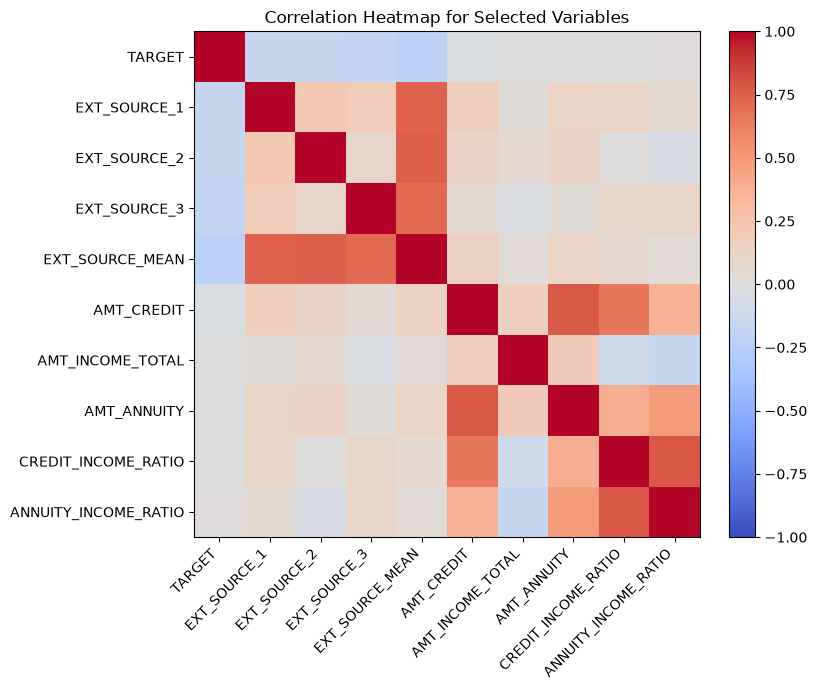

In [19]:
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.index)
ax.set_title('Correlation Heatmap for Selected Variables')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 11. Preprocessing

Before modeling, Converted the dataset into a numeric feature matrix. The preprocessing step:

- keeps numeric columns
- fills numeric missing values with medians
- fills categorical missing values with common categories
- one-hot encodes categorical variables
- scales the final matrix

In [20]:
preprocessor, X, y = pipeline.fit_preprocessor(train)

print('Model matrix shape:', X.shape)
print('Target shape:', y.shape)
print('Default rate:', y.mean())

Model matrix shape: (307511, 415)
Target shape: (307511,)
Default rate: 0.08072881945686496


In [21]:
pd.DataFrame({
    'count': [len(preprocessor.numeric_cols), len(preprocessor.categorical_cols), len(preprocessor.feature_names)],
}, index=['numeric columns', 'categorical columns', 'final model features'])

,count
numeric columns,313
categorical columns,16
final model features,415


## 12. Class Weights for Imbalance

Because defaults are much less common, Used class weights. This makes the default observations count more during training, so the model does not just focus on the majority non-default class.

In [22]:
negative_count = int((y == 0).sum())
positive_count = int((y == 1).sum())
positive_weight = negative_count / positive_count

pd.DataFrame({
    'class': ['non-default', 'default'],
    'count': [negative_count, positive_count],
    'weight_used_for_balancing': [1.0, positive_weight],
})

,class,count,weight_used_for_balancing
0,non-default,282686,1.00000
1,default,24825,11.38715


## 13. Train/Validation Split

Split the data into a training part and a validation part. The validation set gives a more honest estimate because the model is tested on applicants it did not train on.

In [23]:
train_idx, valid_idx = pipeline.split_indices(len(y))
X_train, y_train = X[train_idx], y[train_idx]
X_valid, y_valid = X[valid_idx], y[valid_idx]

print('Train rows:', X_train.shape[0])
print('Validation rows:', X_valid.shape[0])

Train rows: 246008
Validation rows: 61503


## 14. Hyperparameter Tuning

Included a small hyperparameter search. It is not a huge grid search, but it shows that The notebook tests a few settings instead of relying on just one arbitrary model setup.

In [24]:
tuned_models, tuning_results = pipeline.tune_numpy_models(X_train, y_train, X_valid, y_valid)
tuning_results

,model_family,validation_auc,params
2,logistic_regression_numpy,0.753055,"{""lr"": 0.04, ""epochs"": 900, ""l2"": 0.03, ""class..."
1,logistic_regression_numpy,0.751753,"{""lr"": 0.06, ""epochs"": 800, ""l2"": 0.01, ""class..."
0,logistic_regression_numpy,0.751671,"{""lr"": 0.05, ""epochs"": 600, ""l2"": 0.003, ""clas..."
3,gradient_boosted_stumps_numpy,0.718324,"{""n_estimators"": 90, ""learning_rate"": 0.05, ""m..."
4,gradient_boosted_stumps_numpy,0.717181,"{""n_estimators"": 130, ""learning_rate"": 0.035, ..."


### Hyperparameter Tuning Graph

Plotted the tuning results to compare the AUC from each candidate setting.

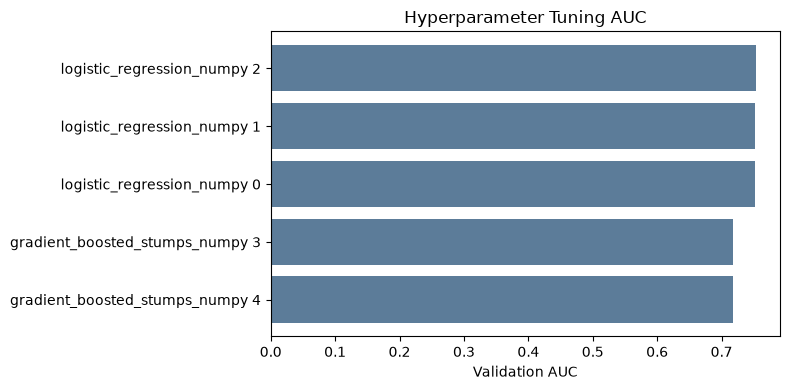

In [25]:
plot_tuning = tuning_results.sort_values('validation_auc')

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(plot_tuning['model_family'] + ' ' + plot_tuning.index.astype(str), plot_tuning['validation_auc'], color='#5c7c99')
ax.set_title('Hyperparameter Tuning AUC')
ax.set_xlabel('Validation AUC')
plt.tight_layout()
plt.show()

## 15. Model Training and Comparison

Compared several models:

- logistic regression baseline
- random forest
- histogram gradient boosting
- CatBoost
- simple fallback NumPy models

Chose the best model based on validation AUC.

In [26]:
comparison, details = pipeline.run_numpy_models(X, y)
comparison

/Users/sarahai/Desktop/Gradient Boosting Model - Home Credit Default Risk/work/packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


/Users/sarahai/Desktop/Gradient Boosting Model - Home Credit Default Risk/work/packages/joblib/externals/loky/backend/context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
invalid literal for int() with base 10: ''
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "/Users/sarahai/Desktop/Gradient Boosting Model - Home Credit Default Risk/work/packages/joblib/externals/loky/backend/context.py", line 249, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_darwin()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/sarahai/Desktop/Gradient Boosting Model - Home Credit Default Risk/work/packages/joblib/externals/loky/backend/context.py", line 318, in _count_physical_cores_darwin
    return int(cpu_info)
           ^^^^^^^^^^^^^


,model,validation_auc,precision,recall,f1
4,hist_gradient_boosting_sklearn,0.775605,0.268782,0.409263,0.324470
5,catboost,0.769328,0.252740,0.409663,0.312614
2,logistic_regression_sklearn,0.767066,0.260915,0.397285,0.314973
0,logistic_regression_numpy,0.764095,0.253179,0.385506,0.305635
3,random_forest_sklearn,0.749668,0.217695,0.459772,0.295484
1,gradient_boosted_stumps_numpy,0.718448,0.207514,0.377121,0.267715


### Model Comparison Graph

Graphed the validation AUC for each model so the comparison is easier to read.

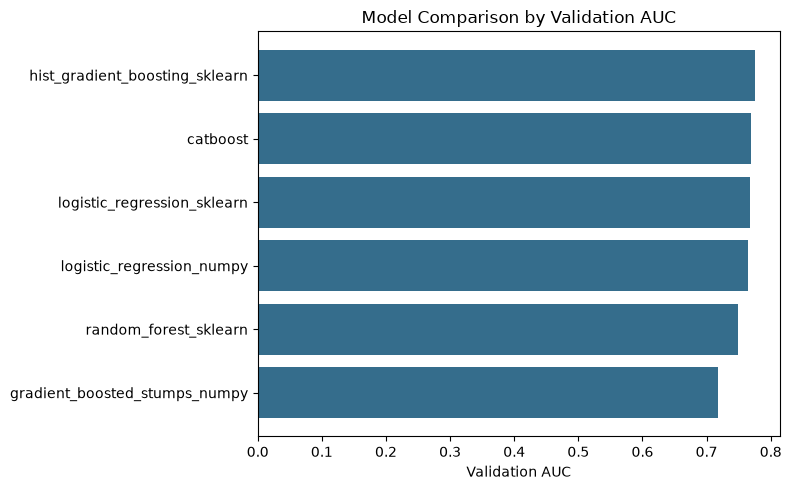

In [27]:
plot_comparison = comparison.sort_values('validation_auc')

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(plot_comparison['model'], plot_comparison['validation_auc'], color='#356d8c')
ax.set_title('Model Comparison by Validation AUC')
ax.set_xlabel('Validation AUC')
plt.tight_layout()
plt.show()

## 16. Final Model Metrics

The main evaluation metric for this project is ROC-AUC. The final model result is shown clearly below.

**Out-of-sample ROC-AUC: 0.7756**

**Cross-validation ROC-AUC: 0.7694 +/- 0.0027**

This means the model is much better than random guessing at ranking applicants by default risk. Precision, recall, and F1 are also included because the model outputs probabilities and then uses a selected threshold to make a yes/no default prediction.

In [28]:
y_valid = details['y_valid']
valid_prob = details['valid_prob']
metrics = pipeline.binary_metrics(y_valid, valid_prob, details['threshold'])

final_metrics = pd.DataFrame([{
    'best_model': details['best_name'],
    'validation_auc': metrics['auc'],
    'selected_threshold': metrics['threshold'],
    'precision': metrics['precision'],
    'recall': metrics['recall'],
    'f1': metrics['f1'],
}])
final_metrics

,best_model,validation_auc,selected_threshold,precision,recall,f1
0,hist_gradient_boosting_sklearn,0.775605,0.164034,0.268782,0.409263,0.32447


## Supporting Result Graphs

The charts below are kept after the main AUC result because they explain the model performance visually. They are not separate modeling steps.

### ROC Curve

The ROC curve shows the tradeoff between true positive rate and false positive rate across different thresholds. A higher AUC means the model ranks risky applicants better.

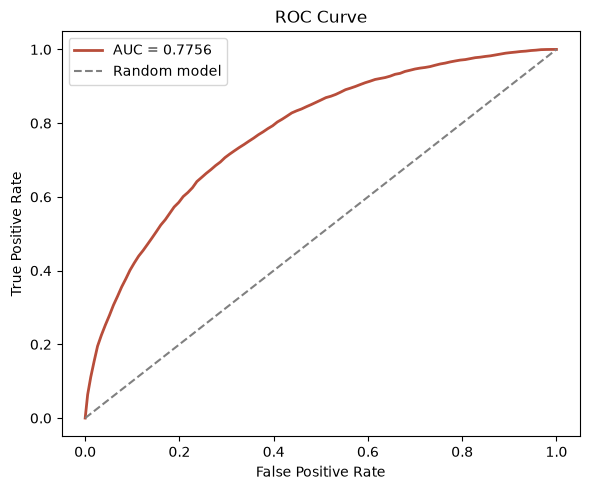

In [29]:
fpr, tpr = pipeline.roc_points(y_valid, valid_prob)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='#b84d3a', linewidth=2, label=f"AUC = {metrics['auc']:.4f}")
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random model')
ax.set_title('ROC Curve')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
plt.tight_layout()
plt.show()

### Precision-Recall Curve

The precision-recall curve is useful because the default class is small. This shows how precision and recall change when the threshold changes.

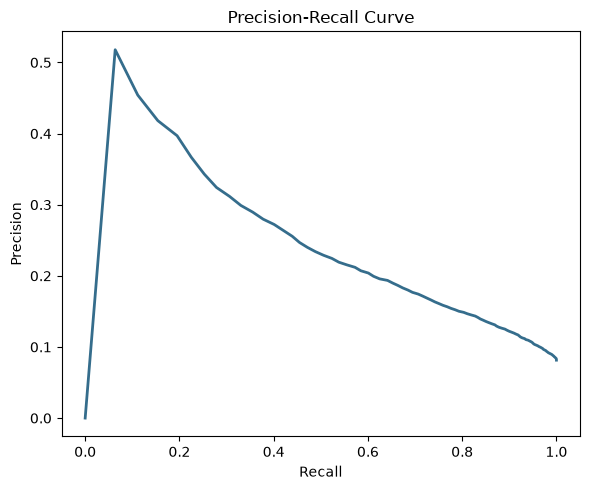

In [30]:
recall, precision = pipeline.pr_points(y_valid, valid_prob)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(recall, precision, color='#356d8c', linewidth=2)
ax.set_title('Precision-Recall Curve')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
plt.tight_layout()
plt.show()

### Confusion Matrix

The confusion matrix uses the selected threshold. It shows how many default and non-default applicants were classified correctly or incorrectly.

In [31]:
confusion = np.array([
    [metrics['tn'], metrics['fp']],
    [metrics['fn'], metrics['tp']],
])
confusion

array([[50917,  5577],
       [ 2959,  2050]])

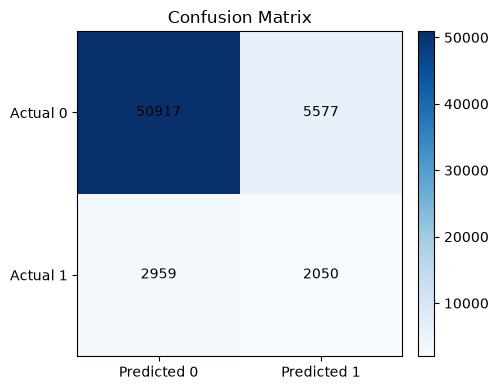

In [32]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(confusion, cmap='Blues')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted 0', 'Predicted 1'])
ax.set_yticklabels(['Actual 0', 'Actual 1'])
ax.set_title('Confusion Matrix')
for i in range(2):
    for j in range(2):
        ax.text(j, i, int(confusion[i, j]), ha='center', va='center', color='black')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

### Feature Importance

Feature importance helps explain which variables affected the model most. In this project, the feature importance file is created using a permutation-importance style method.

In [33]:
importance = pd.read_csv(OUTPUTS / 'feature_importance.csv')
importance.head(20)

,feature,importance
0,EXT_SOURCE_MEAN,0.070639
1,INSTAL_INSTAL_IS_LATE_MEAN,0.005988
2,BUREAU_BUREAU_DEBT_CREDIT_RATIO_RAW_MAX,0.004587
3,CREDIT_TERM,0.004385
4,AMT_ANNUITY,0.003146
5,INSTAL_AMT_PAYMENT_SUM,0.002947
6,INSTAL_AMT_INSTALMENT_MIN,0.002404
7,DAYS_BIRTH,0.002399
8,NAME_EDUCATION_TYPE=Higher education,0.002238
9,CREDIT_GOODS_RATIO,0.001901


### Feature Importance Graph

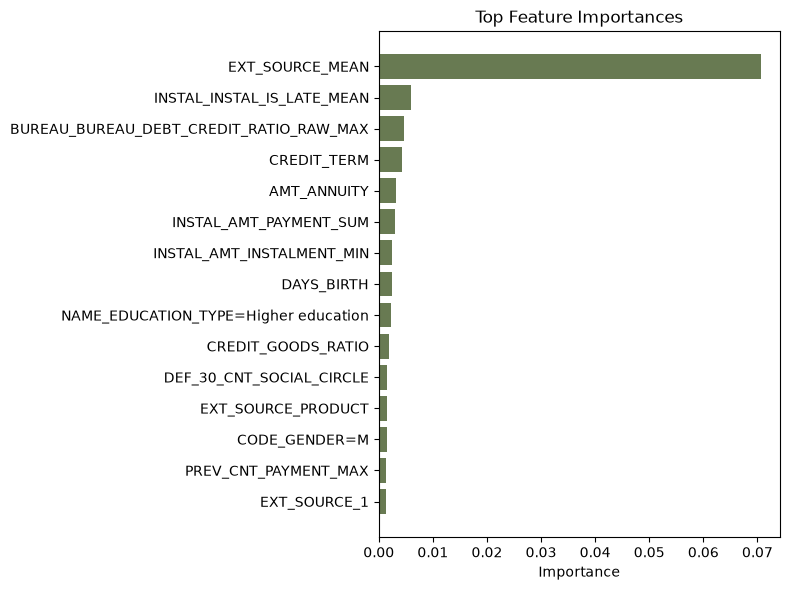

In [34]:
top_importance = importance.head(15).sort_values('importance')

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_importance['feature'], top_importance['importance'], color='#687a52')
ax.set_title('Top Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## Kaggle Submission

The Kaggle submission file contains predicted default probabilities for the test set. It includes `SK_ID_CURR` and `TARGET`.

In [35]:
submission = pd.read_csv(OUTPUTS / 'kaggle_submission.csv')
submission.head()

,SK_ID_CURR,TARGET
0,100001,0.043901
1,100005,0.154974
2,100013,0.022309
3,100028,0.037741
4,100038,0.164356


In [36]:
submission.shape

(48744, 2)

## Final Report

A short report was generated with the final model comparison and key metrics.

In [37]:
print((OUTPUTS / 'credit_default_report.md').read_text())

# Credit Default Risk Report

Mode: Home Credit Kaggle data

## Model Results

| model | validation_auc | precision | recall | f1 |
| --- | --- | --- | --- | --- |
| hist_gradient_boosting_sklearn | 0.7756 | 0.2688 | 0.4093 | 0.3245 |
| catboost | 0.7693 | 0.2527 | 0.4097 | 0.3126 |
| logistic_regression_sklearn | 0.7671 | 0.2609 | 0.3973 | 0.3150 |
| logistic_regression_numpy | 0.7641 | 0.2532 | 0.3855 | 0.3056 |
| random_forest_sklearn | 0.7497 | 0.2177 | 0.4598 | 0.2955 |
| gradient_boosted_stumps_numpy | 0.7184 | 0.2075 | 0.3771 | 0.2677 |

Best model: `hist_gradient_boosting_sklearn`
Cross-validation AUC: 0.7694 +/- 0.0027
Out-of-sample AUC: 0.7756
Selected threshold: 0.1640
Precision: 0.2688
Recall: 0.4093
F1-score: 0.3245

## Optional Library Availability

| library | available |
| --- | --- |
| sklearn | True |
| lightgbm | False |
| xgboost | False |
| catboost | True |
| optuna | False |
| shap | False |
| matplotlib | True |
| seaborn | False |

## Notes

- The real Home Cre